
# 🛍️ Swiggy: Identifying Similar City  – Mini Capstone

## 📌 Problem Statement

Business Context

Swiggy plans to launch a new feature called Smart Delivery Slots, which allows users to schedule food deliveries during peak hours.

Before launching this feature nationwide, the Product team wants to run an A/B experiment in one city.

However, simply comparing the experiment city against the entire country would lead to biased results because every city has different customer behavior, restaurant density, pricing, and conversion rates.

To accurately measure the impact of the experiment, the team needs to identify a control city that closely resembles the experiment city.

For this project, Kolkata has been selected as the experiment city.

Your task is to identify the five most similar cities to Kolkata using historical business metrics.


## Objective:

Build a recommendation engine that identifies cities that are most similar to Kolkata based on available business metrics.

To achieve this:

1. Prepare the dataset.
2. Normalize all numerical features.
3. Use the K-Nearest Neighbors (KNN) algorithm to measure similarity between cities.
4. Identify the Top 5 cities most similar to Kolkata.
5. Visualize the results and explain why these cities are good candidates for a control group


# Data Description


| Column                           | Description                                                                   |
| -------------------------------- | ----------------------------------------------------------------------------- |
| **city**                         | Name of the city                                                              |
| **repeat_user_repeat_rate**      | Average repeat orders placed by existing customers                            |
| **new_user_repeat_rate**         | Average repeat orders placed by newly acquired customers                      |
| **trade_disc_order_percent**     | Percentage of orders where trade discounts were applied                       |
| **free_del_order_percent**       | Percentage of orders with free delivery                                       |
| **ld_order_percent**             | Percentage of orders fulfilled through Long Distance (LD) delivery            |
| **super_pop_coup_order_percent** | Percentage of orders using Super/Popular coupon campaigns                     |
| **aov**                          | Average Order Value (₹)                                                       |
| **abv_99_order_percent**         | Percentage of orders with cart value above ₹99                                |
| **bel_99_order_percent**         | Percentage of orders with cart value below ₹99                                |
| **opd_grwth_percent**            | Growth percentage in Orders Per Day (OPD) compared to the previous period     |
| **overall_conversion**           | Percentage of users who visited the platform and placed an order              |
| **m2o_conversion**               | Menu-to-Order conversion rate (users who viewed menus and completed an order) |
| **rest_numbers**                 | Total number of active restaurants in the city                                |
| **opd_brkfst_perc**              | Percentage of daily orders placed during breakfast hours                      |
| **opd_lunch_perc**               | Percentage of daily orders placed during lunch hours                          |
| **opd_snacks_perc**              | Percentage of daily orders placed during snack hours                          |
| **opd_dinner_perc**              | Percentage of daily orders placed during dinner hours                         |
| **opd_late_night_perc**          | Percentage of daily orders placed during late-night hours                     |
| **completed_orders**             | Average number of successfully completed orders in the city                   |


# Understanding These Metrics

What do these metrics represent?

The dataset captures four major dimensions of every city:

1. Customer Behaviour
Repeat User Repeat Rate
New User Repeat Rate
Overall Conversion
M2O Conversion

These metrics indicate how customers interact with the platform and how likely they are to place orders.

2. Pricing & Promotional Behaviour
Trade Discount %
Free Delivery %
Super Popular Coupon %
AOV
Above ₹99 Order %
Below ₹99 Order %

These describe customer sensitivity to discounts, pricing, and promotional campaigns.

3. Marketplace Characteristics
Restaurant Count
Completed Orders
Long Distance Order %

These reflect the supply side and scale of the marketplace.

4. Demand Pattern
Breakfast %
Lunch %
Snacks %
Dinner %
Late Night %

## Import Libraries and Load the Data 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

# Importing data 
data = pd.read_excel("C:/Users/admin/Desktop/Ed_Tech/Projects/Swiggy_Similar_City.xlsx")
data.head()

# Steps 

| Step                   | What we're doing                           | Why?                                                      |
| ---------------------- | ------------------------------------------ | --------------------------------------------------------- |
| Load Data              | Read city-level metrics                    | Each row is one city                                      |
| Separate Features      | Remove city names                          | ML only works on numbers                                  |
| Normalize              | Scale every metric to 0–1                  | Prevent large-value columns (like orders) from dominating |
| Train NearestNeighbors | Store all cities in feature space          | Builds a structure for fast similarity search             |
| Select Kolkata         | Choose the city of interest                | This is our experiment city                               |
| Find Neighbors         | Calculate Euclidean distance to all cities | Returns the closest cities                                |
| Interpret Results      | Smaller distance = more similar            | Candidate control cities                                  |


In [19]:
data[data['city']=='Kolkata']

,city,repeat_user_repeat_rate,new_user_repeat_rate,trade_disc_order_percent,free_del_order_percent,ld_order_percent,super_pop_coup_order_percent,aov,abv_99_order_percent,bel_99_order_percent,opd_grwth_percent,overall_conversion,m2o_conversion,rest_numbers,opd_brkfst_perc,opd_lunch_perc,opd_snacks_perc,opd_dinner_perc,opd_late_night_perc,completed_orders
52,Kolkata,2.611905,1.320432,62.901882,29.073051,22.326479,80.865745,299.056057,92.114075,7.885925,-1.327769,0.222307,0.580342,2887,5.296112,28.117435,18.77552,42.353558,5.457374,40041.5


In [2]:


# -----------------------------
# Step 1: Load the Data
# -----------------------------
df = data.copy()

# -----------------------------
# Step 2: Separate Features
# We don't want the city name while calculating similarity  
#-----------------------------
city_names = df["city"]
X = df.drop(columns=["city"])

# -----------------------------
# Step 3: Normalize Features
# Since different metrics have different scales, we normalize them between 0 and 1.
# -----------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Step 4: Train KNN Model
# -----------------------------
model = NearestNeighbors(
    n_neighbors=6,
    metric="euclidean"
)

model.fit(X_scaled)

# -----------------------------
# Step 5: Locate Kolkata
# We first search the DataFrame for the row where the city is Kolkata
# -----------------------------
kolkata_index = df[df["city"] == "Kolkata"].index[0]

# -----------------------------
# Step 6: Find Similar Cities
# -----------------------------
distances, indices = model.kneighbors(
    X_scaled[kolkata_index].reshape(1, -1)
)

# -----------------------------
# Step 7: Show Results
# -----------------------------
results = pd.DataFrame({
    "City": city_names.iloc[indices[0]].values,
    "Distance": distances[0]
})

results = results.iloc[1:].reset_index(drop=True)

print(results)

         City  Distance
0      Jaipur  0.634174
1  Chandigarh  0.647859
2        Pune  0.669117
3      Nagpur  0.752961
4   Ahmedabad  0.775259


## For Understanding

In [24]:
# What is X_scaled ? What is X


#print(X.head(1))
#print(X_scaled[0])

#model

distances

array([[4.21468485e-08, 6.34174488e-01, 6.47858900e-01, 6.69116634e-01,
        7.52960845e-01, 7.75259032e-01]])

# How Does the Algo Works

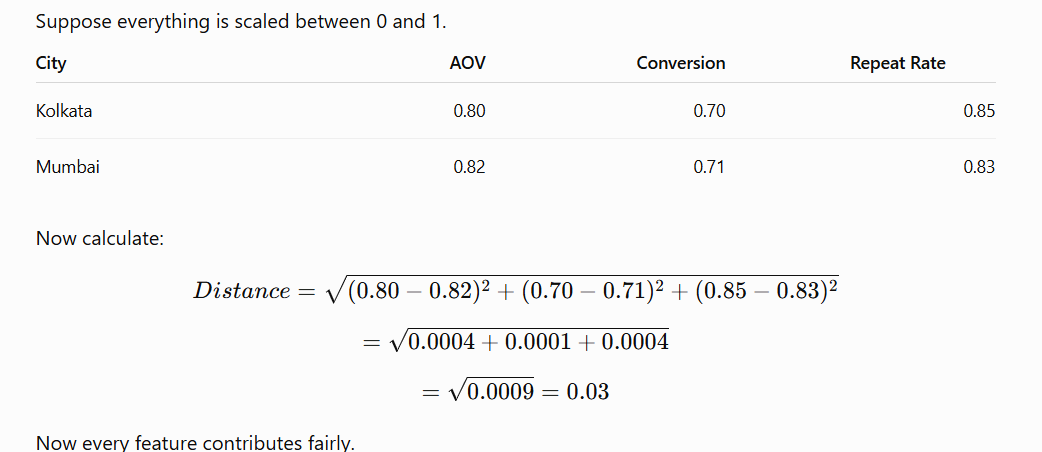


## This is how distances would look like:

| City      | Distance |
| --------- | -------: |
| Kolkata   |    0.000 |
| Mumbai    |    0.042 |
| Pune      |    0.061 |
| Bangalore |    0.075 |
| Hyderabad |    0.091 |
| NCR       |    0.108 |
| Jaipur    |    0.331 |
